# 1. Structural Auditory

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

def section(t): 
    print("\n" + "="*80); print(t); print("="*80)

def session(title):
    section(f"SESSION: {title}")
    print("Problem -> Data -> QA -> Summaries -> EDA -> Conclusión -> Next")

def glance(df, name="df", n=3):
    section(f"GLANCE: {name}")
    print("shape:", df.shape)
    print("dups:", df.duplicated().sum())
    na = df.isna().sum()
    na = na[na>0].sort_values(ascending=False)
    print("missing cols:", len(na))
    if len(na): display(na.head(25))
    display(df.head(n))
    display(df.dtypes.to_frame("dtype"))

def checks(df, required=None, key=None, dt=None):
    section("QA CHECKS")
    ok = True
    
    if required:
        miss = [c for c in required if c not in df.columns]
        if miss:
            ok = False
            print("❌ missing columns:", miss)
        else:
            print("✅ required columns ok")

    if key:
        d = df.duplicated(subset=key).sum()
        if d:
            ok = False
            print(f"❌ duplicated key rows: {d} (key={key})")
        else:
            print(f"✅ unique key ok (key={key})")

    if dt:
        if dt not in df.columns:
            ok = False
            print(f"❌ datetime col not found: {dt}")
        elif not np.issubdtype(df[dt].dtype, np.datetime64):
            ok = False
            print(f"❌ {dt} is {df[dt].dtype} (expected datetime64)")
        else:
            print(f"✅ datetime ok: {dt}")

    print("\nRESULT:", "✅ PASS" if ok else "❌ FAIL")
    return ok

def num_summary(df):
    section("NUMERIC SUMMARY")
    cols = df.select_dtypes(include=[np.number]).columns
    display(df[cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T.assign(
        missing=df[cols].isna().sum(),
        missing_pct=lambda x: x["missing"]/len(df)
    ).sort_values("missing_pct", ascending=False))

In [13]:
# --- find project root (folder that contains /data) ---
def find_project_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "data").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No encuentro la raíz del proyecto (no veo /data en padres).")

ROOT = find_project_root(Path.cwd())
# C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\master\master_tfe_2015_2024.parquet
FP = ROOT / "data" / "processed" / "tenerife" / "master" / "master_tfe_2015_2024.parquet"

print("ROOT:", ROOT)
print("FP:", FP)
assert FP.exists(), f"No existe: {FP}"

session("EDA core weekly Tenerife")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

glance(df, "eda_core_weekly_tfe")

checks(df,
       required=["week_start","deaths_week"],
       key=["week_start"],
       dt="week_start")

num_summary(df)

ROOT: C:\dev\projects\heat_mortality_analysis
FP: C:\dev\projects\heat_mortality_analysis\data\processed\tenerife\master\master_tfe_2015_2024.parquet

SESSION: EDA core weekly Tenerife
Problem -> Data -> QA -> Summaries -> EDA -> Conclusión -> Next

GLANCE: eda_core_weekly_tfe
shape: (471, 35)
dups: 0
missing cols: 7


cap_heat_level_max_week      129
cap_heat_yellow_plus_week    129
cap_dust_level_max_week      129
cap_dust_yellow_plus_week    129
cap_coverage_week            129
O3                             1
NO2                            1
dtype: int64

,week_start,year,island,island_code,deaths_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,pressure_hpa_mean,...,NO2,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag
0,2015-12-28,2015,tenerife,tfe,129.0,19.300000,23.966667,14.666667,67.333333,1016.700000,...,74.333333,54.000000,3,0,NaN,NaN,NaN,NaN,NaN,blue
1,2016-01-04,2016,tenerife,tfe,132.0,19.100000,23.342857,14.828571,65.428571,1013.242857,...,72.857143,56.571429,7,0,NaN,NaN,NaN,NaN,NaN,blue
2,2016-01-11,2016,tenerife,tfe,162.0,21.642857,26.042857,17.242857,57.571429,1011.921429,...,87.857143,46.571429,7,0,NaN,NaN,NaN,NaN,NaN,blue


,dtype
week_start,datetime64[ns]
year,int32
island,object
island_code,object
deaths_week,float64
temp_c_mean,float64
tmax_c_mean,float64
tmin_c_mean,float64
humidity_mean,float64
pressure_hpa_mean,float64



QA CHECKS
✅ required columns ok
✅ unique key ok (key=['week_start'])
✅ datetime ok: week_start

RESULT: ✅ PASS

NUMERIC SUMMARY


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,missing_pct
cap_dust_yellow_plus_week,342.0,0.055556,0.229397,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,129,0.273885
cap_heat_yellow_plus_week,342.0,0.122807,0.328696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,129,0.273885
cap_heat_level_max_week,342.0,1.154971,0.455615,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,4.000000,129,0.273885
cap_coverage_week,342.0,0.993317,0.045932,0.285714,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,129,0.273885
cap_dust_level_max_week,342.0,1.055556,0.229397,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,129,0.273885
NO2,470.0,48.267847,21.338687,9.714286,13.635714,18.128571,30.636905,46.214286,63.250000,82.664286,95.231429,177.714286,1,0.002123
O3,470.0,68.369524,14.092542,32.285714,37.744286,45.857143,58.607143,68.000000,77.250000,91.342857,105.157143,120.285714,1,0.002123
wind_ms_mean,471.0,6.242013,1.527180,3.057143,3.487143,3.907143,5.036905,6.228571,7.364286,8.792857,9.860000,10.942857,0,0.000000
year,471.0,2019.993631,2.594996,2015.000000,2016.000000,2016.000000,2018.000000,2020.000000,2022.000000,2024.000000,2024.000000,2024.000000,0,0.000000
deaths_week,471.0,138.641189,21.618765,92.000000,99.700000,108.000000,123.000000,137.000000,151.000000,179.500000,195.600000,214.000000,0,0.000000


### 1.CAP solo usable desde 2018

### 2.DAI flags no disponibles después de marzo de 2022

# Fase1. Temperature Vs Deaths.
## ¿Semanas más cálidas se asocian con más muertes semanales?
## ¿esa relación parece lineal, débil, fuerte o engañosa por estacionalidad?

Rows: 471
Range: 2015-12-28 00:00:00 -> 2024-12-30 00:00:00
Pearson corr (tmax vs deaths): -0.344
Spearman corr (tmax vs deaths): -0.389
Linear fit:
deaths_week = -2.621 * tmax_c_mean + 206.849


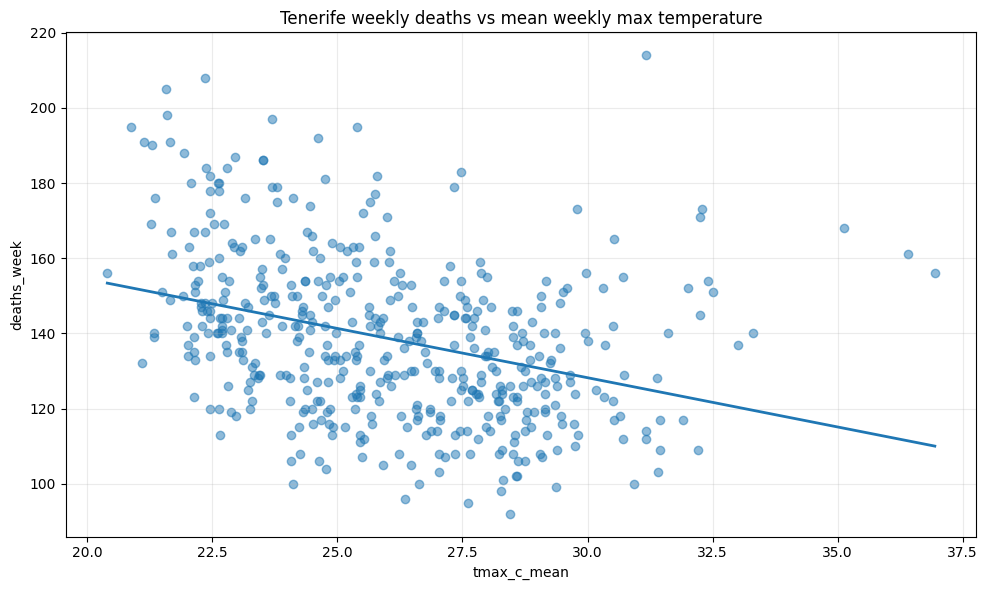

In [14]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

# Keep rows with both variables present
sub = df[["week_start", "deaths_week", "tmax_c_mean"]].dropna().copy()

print("Rows:", len(sub))
print("Range:", sub["week_start"].min(), "->", sub["week_start"].max())

# =========================
# CORRELATIONS
# =========================

pearson = sub["tmax_c_mean"].corr(sub["deaths_week"], method="pearson")
spearman = sub["tmax_c_mean"].corr(sub["deaths_week"], method="spearman")

print("Pearson corr (tmax vs deaths):", round(pearson, 3))
print("Spearman corr (tmax vs deaths):", round(spearman, 3))

# =========================
# SIMPLE LINEAR FIT
# =========================

x = sub["tmax_c_mean"].values
y = sub["deaths_week"].values

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

print("Linear fit:")
print("deaths_week =", round(slope, 3), "* tmax_c_mean +", round(intercept, 3))

# =========================
# PLOT 1: SCATTER + TREND
# =========================

plt.figure(figsize=(10, 6))
plt.scatter(sub["tmax_c_mean"], sub["deaths_week"], alpha=0.5)
plt.plot(x_line, y_line, linewidth=2)

plt.title("Tenerife weekly deaths vs mean weekly max temperature")
plt.xlabel("tmax_c_mean")
plt.ylabel("deaths_week")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

                       tmax_bin  temp_mean  deaths_mean  deaths_std   n  \
0  (20.398999999999997, 22.457]  21.961998   158.549020   21.922877  51   
1              (22.457, 23.217]  22.847078   148.204545   18.556738  44   
2              (23.217, 24.229]  23.741369   145.270833   21.658608  48   
3              (24.229, 24.914]  24.587940   138.173913   20.912840  46   
4              (24.914, 25.757]  25.372594   140.340426   20.196079  47   
5              (25.757, 26.714]  26.243769   134.574468   18.003315  47   
6                (26.714, 27.7]  27.283780   130.791667   18.653570  48   
7                (27.7, 28.557]  28.135549   126.782609   15.388182  46   
8              (28.557, 29.471]  28.990578   125.957447   13.806044  47   
9              (29.471, 36.943]  31.213171   136.446809   23.389712  47   

         se      ci95  
0  3.069817  6.016841  
1  2.797534  5.483166  
2  3.126151  6.127256  
3  3.083430  6.043523  
4  2.945901  5.773966  
5  2.626053  5.147065  
6  2.6

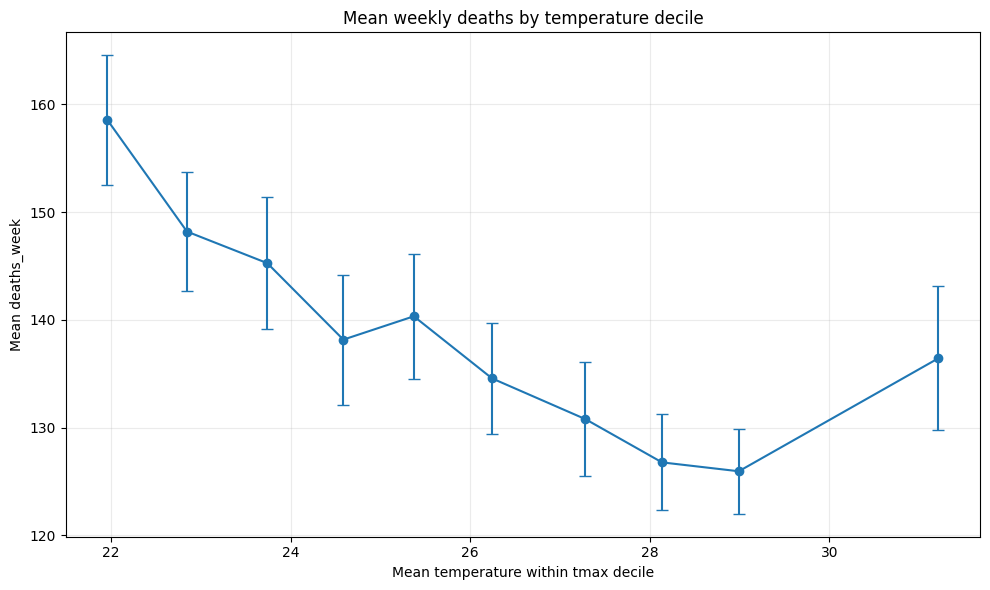

In [15]:
# =========================
# BINNED TEMPERATURE PLOT
# =========================

tmp = sub.copy()

# 10 bins by quantiles
tmp["tmax_bin"] = pd.qcut(tmp["tmax_c_mean"], q=10, duplicates="drop")

bin_summary = (
    tmp.groupby("tmax_bin", observed=True)
       .agg(
           temp_mean=("tmax_c_mean", "mean"),
           deaths_mean=("deaths_week", "mean"),
           deaths_std=("deaths_week", "std"),
           n=("deaths_week", "size")
       )
       .reset_index()
)

bin_summary["se"] = bin_summary["deaths_std"] / np.sqrt(bin_summary["n"])
bin_summary["ci95"] = 1.96 * bin_summary["se"]

print(bin_summary)

plt.figure(figsize=(10, 6))
plt.errorbar(
    bin_summary["temp_mean"],
    bin_summary["deaths_mean"],
    yerr=bin_summary["ci95"],
    fmt="-o",
    capsize=4
)

plt.title("Mean weekly deaths by temperature decile")
plt.xlabel("Mean temperature within tmax decile")
plt.ylabel("Mean deaths_week")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

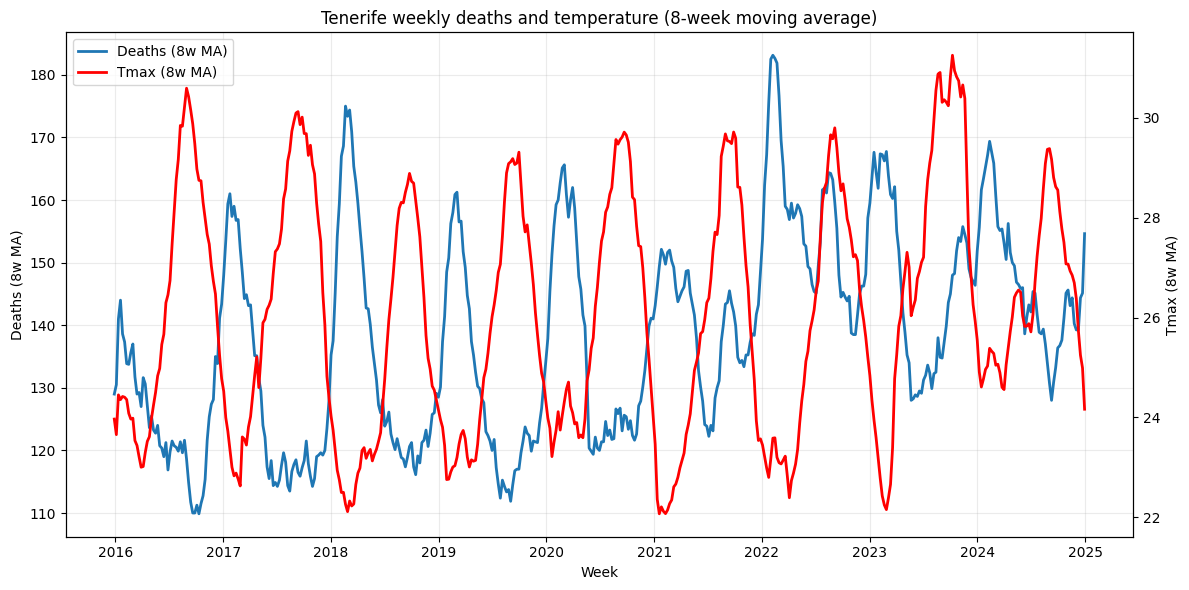

In [19]:
# =========================
# TIME SERIES (SMOOTHED)
# =========================

ts = sub.sort_values("week_start").copy()
ts["deaths_ma8"] = ts["deaths_week"].rolling(8, min_periods=1).mean()
ts["tmax_ma8"] = ts["tmax_c_mean"].rolling(8, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(ts["week_start"], ts["deaths_ma8"], linewidth=2, label="Deaths (8w MA)")
ax1.set_ylabel("Deaths (8w MA)")
ax1.set_xlabel("Week")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(ts["week_start"], ts["tmax_ma8"], color="red", linewidth=2, label="Tmax (8w MA)")
ax2.set_ylabel("Tmax (8w MA)")

plt.title("Tenerife weekly deaths and temperature (8-week moving average)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
plt.show()

En el análisis exploratorio inicial, la temperatura máxima media semanal muestra una asociación negativa moderada con la mortalidad semanal en Tenerife. Tanto la correlación lineal como el análisis por deciles térmicos indican que las semanas más frías presentan, en promedio, mayor mortalidad que las más cálidas. Sin embargo, esta relación debe interpretarse con cautela, ya que probablemente refleja en gran medida la estacionalidad de fondo de la serie más que un efecto causal directo de la temperatura. El leve repunte observado en el decil térmico más alto sugiere además que la relación podría no ser estrictamente lineal.

Aunque la asociación contemporánea entre temperatura máxima media semanal y mortalidad semanal es negativa en la serie completa, la inspección visual de medias móviles sugiere la posible existencia de una relación retardada, en la que algunos periodos de temperaturas elevadas parecen preceder repuntes posteriores de mortalidad. Esto indica que la relación temperatura–mortalidad podría estar parcialmente desplazada en el tiempo y no describirse bien mediante correlaciones de misma semana.

## Tabla de correlaciones por lag

In [21]:
sub = df[["week_start", "tmax_c_mean", "deaths_week"]].dropna().copy()

# =========================
# LAG CORRELATIONS
# =========================

rows = []

for lag in range(0, 7):
    tmp = sub.copy()
    tmp[f"deaths_lag{lag}"] = tmp["deaths_week"].shift(-lag)
    tmp = tmp.dropna(subset=["tmax_c_mean", f"deaths_lag{lag}"]).copy()
    
    pearson = tmp["tmax_c_mean"].corr(tmp[f"deaths_lag{lag}"], method="pearson")
    spearman = tmp["tmax_c_mean"].corr(tmp[f"deaths_lag{lag}"], method="spearman")
    
    rows.append({
        "lag_weeks": lag,
        "n": len(tmp),
        "pearson": pearson,
        "spearman": spearman
    })

lag_corr = pd.DataFrame(rows)

print(lag_corr.round(3))

   lag_weeks    n  pearson  spearman
0          0  471   -0.344    -0.389
1          1  470   -0.373    -0.414
2          2  469   -0.374    -0.402
3          3  468   -0.352    -0.375
4          4  467   -0.313    -0.328
5          5  466   -0.289    -0.310
6          6  465   -0.259    -0.282


# Bloque 2. Grafica de correlaciones por lag

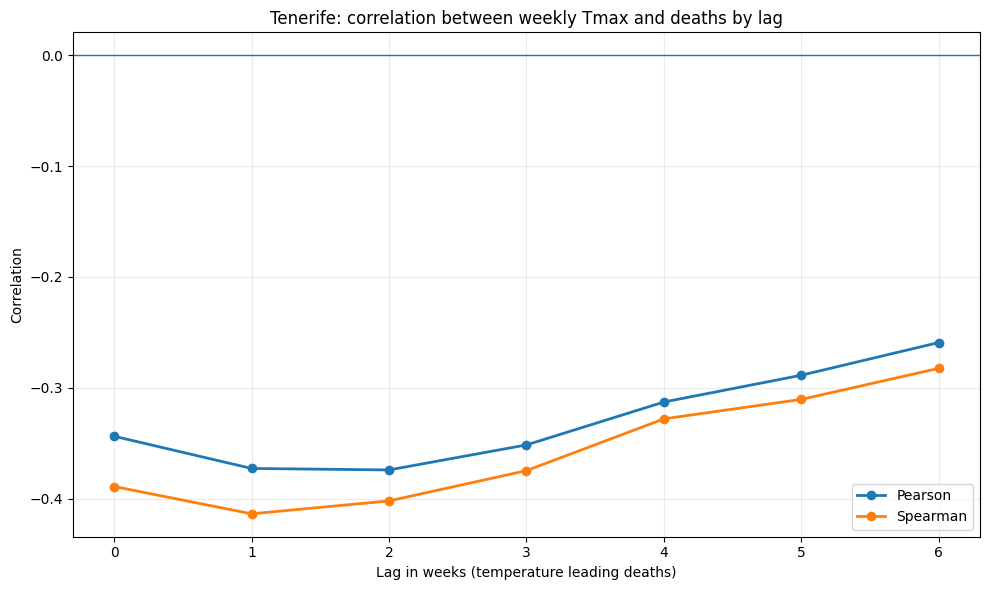

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(lag_corr["lag_weeks"], lag_corr["pearson"], marker="o", linewidth=2, label="Pearson")
plt.plot(lag_corr["lag_weeks"], lag_corr["spearman"], marker="o", linewidth=2, label="Spearman")

plt.axhline(0, linewidth=1)
plt.xticks(lag_corr["lag_weeks"])
plt.xlabel("Lag in weeks (temperature leading deaths)")
plt.ylabel("Correlation")
plt.title("Tenerife: correlation between weekly Tmax and deaths by lag")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Bloque 3: Scatter del mejor pearson

Best lag by Pearson: 6
Linear fit at best lag:
deaths_future = -1.986 * tmax_c_mean + 190.388


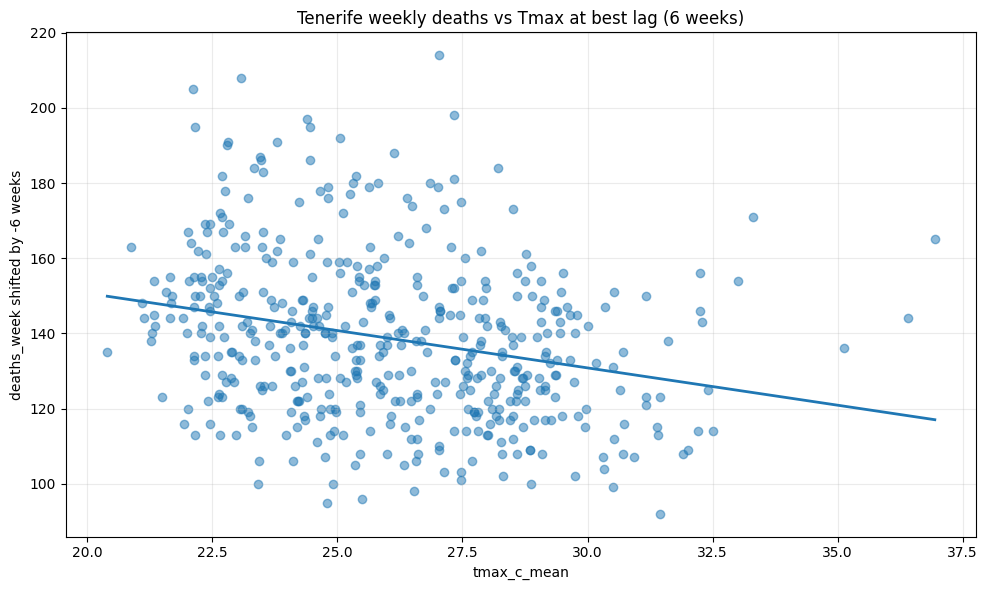

In [23]:
best_lag = lag_corr.loc[lag_corr["pearson"].idxmax(), "lag_weeks"]
print("Best lag by Pearson:", best_lag)

tmp = sub.copy()
tmp["deaths_best_lag"] = tmp["deaths_week"].shift(-int(best_lag))
tmp = tmp.dropna(subset=["tmax_c_mean", "deaths_best_lag"]).copy()

x = tmp["tmax_c_mean"].values
y = tmp["deaths_best_lag"].values

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

print("Linear fit at best lag:")
print("deaths_future =", round(slope, 3), "* tmax_c_mean +", round(intercept, 3))

plt.figure(figsize=(10, 6))
plt.scatter(tmp["tmax_c_mean"], tmp["deaths_best_lag"], alpha=0.5)
plt.plot(x_line, y_line, linewidth=2)

plt.title(f"Tenerife weekly deaths vs Tmax at best lag ({int(best_lag)} weeks)")
plt.xlabel("tmax_c_mean")
plt.ylabel(f"deaths_week shifted by -{int(best_lag)} weeks")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Bloque 4 medias por bin en el mejor lag

                       tmax_bin  temp_mean  deaths_mean  deaths_std   n    se  \
0  (20.398999999999997, 22.457]      21.95       147.31       17.98  48  2.59   
1               (22.457, 23.28]      22.87       147.36       23.07  45  3.44   
2               (23.28, 24.251]      23.77       142.09       22.94  47  3.35   
3              (24.251, 24.957]      24.62       139.87       23.53  47  3.43   
4              (24.957, 25.786]      25.42       143.74       21.71  46  3.20   
5              (25.786, 26.754]      26.27       134.85       21.05  46  3.10   
6              (26.754, 27.723]      27.30       140.26       25.70  46  3.79   
7              (27.723, 28.574]      28.14       130.11       16.83  47  2.46   
8               (28.574, 29.48]      29.00       132.57       15.04  46  2.22   
9               (29.48, 36.943]      31.21       128.55       18.85  47  2.75   

   ci95  
0  5.09  
1  6.74  
2  6.56  
3  6.73  
4  6.27  
5  6.08  
6  7.43  
7  4.81  
8  4.35  
9  5.39 

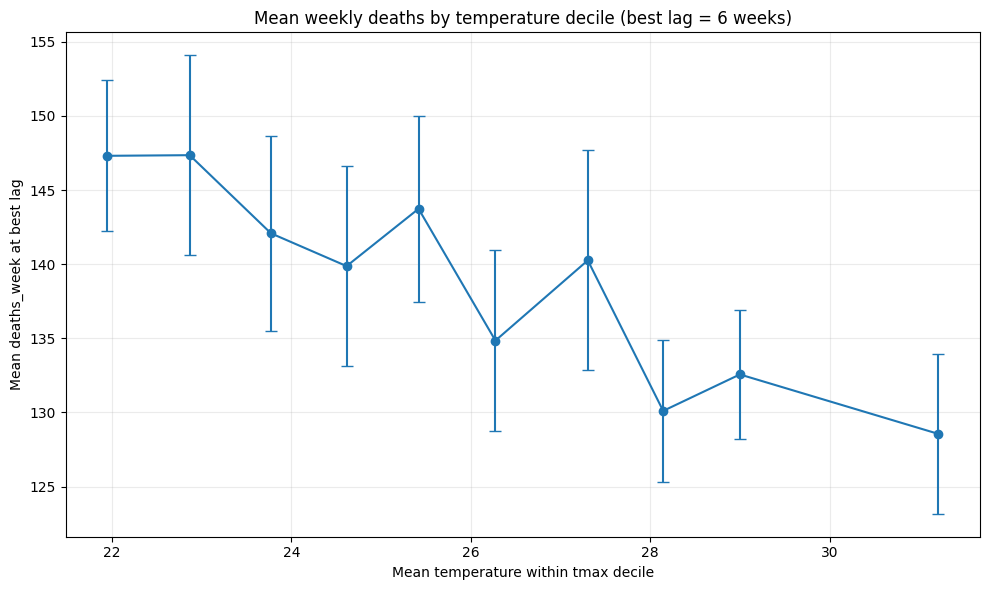

In [24]:
tmp2 = tmp.copy()
tmp2["tmax_bin"] = pd.qcut(tmp2["tmax_c_mean"], q=10, duplicates="drop")

bin_summary_lag = (
    tmp2.groupby("tmax_bin", observed=True)
        .agg(
            temp_mean=("tmax_c_mean", "mean"),
            deaths_mean=( "deaths_best_lag", "mean"),
            deaths_std=("deaths_best_lag", "std"),
            n=("deaths_best_lag", "size")
        )
        .reset_index()
)

bin_summary_lag["se"] = bin_summary_lag["deaths_std"] / np.sqrt(bin_summary_lag["n"])
bin_summary_lag["ci95"] = 1.96 * bin_summary_lag["se"]

print(bin_summary_lag.round(2))

plt.figure(figsize=(10, 6))
plt.errorbar(
    bin_summary_lag["temp_mean"],
    bin_summary_lag["deaths_mean"],
    yerr=bin_summary_lag["ci95"],
    fmt="-o",
    capsize=4
)

plt.title(f"Mean weekly deaths by temperature decile (best lag = {int(best_lag)} weeks)")
plt.xlabel("Mean temperature within tmax decile")
plt.ylabel("Mean deaths_week at best lag")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

El análisis de correlaciones con desfases de 0 a 6 semanas no muestra evidencia de una asociación positiva retardada entre temperatura máxima media semanal y mortalidad semanal. En todos los lags analizados, la relación permanece negativa, aunque se debilita progresivamente a medida que aumenta el desfase. Esto sugiere que, en la serie agregada completa, la temperatura sigue reflejando sobre todo la estructura estacional de fondo y no un efecto lineal retardado simple del calor sobre la mortalidad.

## Hay suficiente variacion termica extrema?

In [25]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

# Umbrales
p90 = df["tmax_c_mean"].quantile(0.90)
p95 = df["tmax_c_mean"].quantile(0.95)
p99 = df["tmax_c_mean"].quantile(0.99)

print("tmax_c_mean thresholds")
print("p90:", round(p90, 2))
print("p95:", round(p95, 2))
print("p99:", round(p99, 2))

# Conteos
df["heat_p90"] = (df["tmax_c_mean"] >= p90).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= p95).astype(int)
df["heat_p99"] = (df["tmax_c_mean"] >= p99).astype(int)

print("\nCounts")
print("heat_p90:", df["heat_p90"].sum())
print("heat_p95:", df["heat_p95"].sum())
print("heat_p99:", df["heat_p99"].sum())

# Reparto por año
year_counts = (
    df.groupby(df["week_start"].dt.year)[["heat_p90", "heat_p95", "heat_p99"]]
      .sum()
)

print("\nExtreme heat weeks by year")
print(year_counts)

# Top semanas más cálidas
top_hot = (
    df[["week_start", "tmax_c_mean", "deaths_week", "cap_heat_yellow_plus_week"]]
    .sort_values("tmax_c_mean", ascending=False)
    .head(20)
)

print("\nTop 20 hottest weeks")
print(top_hot.to_string(index=False))

tmax_c_mean thresholds
p90: 29.47
p95: 30.71
p99: 32.65

Counts
heat_p90: 48
heat_p95: 25
heat_p99: 5

Extreme heat weeks by year
            heat_p90  heat_p95  heat_p99
week_start                              
2015               0         0         0
2016               8         4         0
2017               9         5         0
2018               0         0         0
2019               3         2         0
2020               4         2         0
2021               3         2         1
2022               5         2         0
2023              11         7         4
2024               5         1         0

Top 20 hottest weeks
week_start  tmax_c_mean  deaths_week  cap_heat_yellow_plus_week
2023-10-02    36.942857        156.0                        1.0
2023-10-09    36.414286        161.0                        1.0
2021-08-16    35.128571        168.0                        1.0
2023-07-10    33.300000        140.0                        1.0
2023-08-14    33.014286        137.0

Deaths by heat_p90
          count    mean  median    std    min    max
heat_p90                                            
0           423  138.93   138.0  21.43   92.0  208.0
1            48  136.06   133.0  23.29  100.0  214.0

Deaths by heat_p95
          count    mean  median    std    min    max
heat_p95                                            
0           446  138.64   137.0  21.28   92.0  208.0
1            25  138.68   140.0  27.49  100.0  214.0


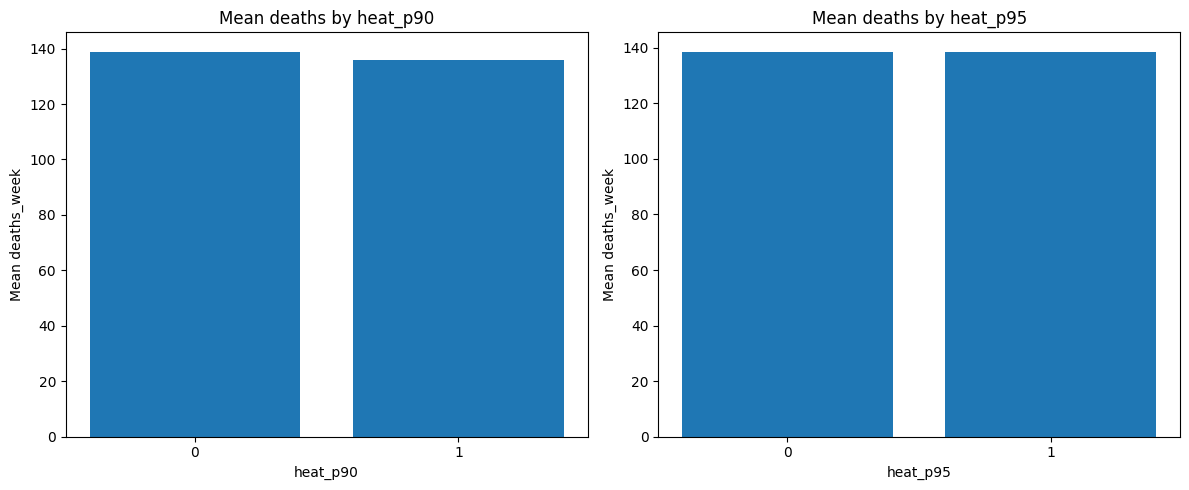

In [27]:
df = pd.read_parquet(FP).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

# Thresholds
p90 = df["tmax_c_mean"].quantile(0.90)
p95 = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= p90).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= p95).astype(int)

# Summary by heat flags
print("Deaths by heat_p90")
print(
    df.groupby("heat_p90")["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

print("\nDeaths by heat_p95")
print(
    df.groupby("heat_p95")["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

# Plot 1: mean deaths by heat flag
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

p90_summary = df.groupby("heat_p90")["deaths_week"].mean()
p95_summary = df.groupby("heat_p95")["deaths_week"].mean()

axes[0].bar(p90_summary.index.astype(str), p90_summary.values)
axes[0].set_title("Mean deaths by heat_p90")
axes[0].set_xlabel("heat_p90")
axes[0].set_ylabel("Mean deaths_week")

axes[1].bar(p95_summary.index.astype(str), p95_summary.values)
axes[1].set_title("Mean deaths by heat_p95")
axes[1].set_xlabel("heat_p95")
axes[1].set_ylabel("Mean deaths_week")

plt.tight_layout()
plt.show()

In [29]:
df = pd.read_parquet(FP).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").copy()

# Semana ISO
iso = df["week_start"].dt.isocalendar()
df["iso_week"] = iso.week.astype(int)
df["iso_year"] = iso.year.astype(int)

# Climatología semanal simple: media histórica de tmax por semana ISO
weekly_clim = (
    df.groupby("iso_week", as_index=False)["tmax_c_mean"]
      .mean()
      .rename(columns={"tmax_c_mean": "tmax_clim_mean"})
)

df = df.merge(weekly_clim, on="iso_week", how="left")

# Anomalía térmica
df["tmax_anomaly"] = df["tmax_c_mean"] - df["tmax_clim_mean"]

print(df[["week_start", "tmax_c_mean", "tmax_clim_mean", "tmax_anomaly"]].head(10).to_string(index=False))

print("\nSummary of tmax_anomaly")
print(df["tmax_anomaly"].describe().round(2))

# Correlaciones simples
pearson = df["tmax_anomaly"].corr(df["deaths_week"], method="pearson")
spearman = df["tmax_anomaly"].corr(df["deaths_week"], method="spearman")

print("\nCorrelations: anomaly vs deaths")
print("Pearson:", round(pearson, 3))
print("Spearman:", round(spearman, 3))

week_start  tmax_c_mean  tmax_clim_mean  tmax_anomaly
2015-12-28    23.966667       22.533333      1.433333
2016-01-04    23.342857       23.064286      0.278571
2016-01-11    26.042857       22.959524      3.083333
2016-01-18    24.071429       22.861111      1.210317
2016-01-25    24.671429       22.774603      1.896825
2016-02-01    24.328571       23.479101      0.849471
2016-02-08    24.071429       23.526984      0.544444
2016-02-15    22.157143       23.806349     -1.649206
2016-02-22    23.042857       22.955556      0.087302
2016-02-29    23.485714       23.122222      0.363492

Summary of tmax_anomaly
count    471.00
mean       0.00
std        1.52
min       -2.89
25%       -1.04
50%       -0.32
75%        0.83
max        8.01
Name: tmax_anomaly, dtype: float64

Correlations: anomaly vs deaths
Pearson: 0.068
Spearman: 0.028


In [30]:
rows = []

sub = df[["week_start", "tmax_anomaly", "deaths_week"]].dropna().copy()

for lag in range(0, 7):
    tmp = sub.copy()
    tmp[f"deaths_lag{lag}"] = tmp["deaths_week"].shift(-lag)
    tmp = tmp.dropna()

    rows.append({
        "lag_weeks": lag,
        "pearson": tmp["tmax_anomaly"].corr(tmp[f"deaths_lag{lag}"], method="pearson"),
        "spearman": tmp["tmax_anomaly"].corr(tmp[f"deaths_lag{lag}"], method="spearman"),
        "n": len(tmp)
    })

lag_anom = pd.DataFrame(rows)
print(lag_anom.round(3))

   lag_weeks  pearson  spearman    n
0          0    0.068     0.028  471
1          1    0.010    -0.033  470
2          2    0.010    -0.011  469
3          3    0.008    -0.002  468
4          4    0.038     0.024  467
5          5    0.024     0.011  466
6          6    0.004    -0.014  465


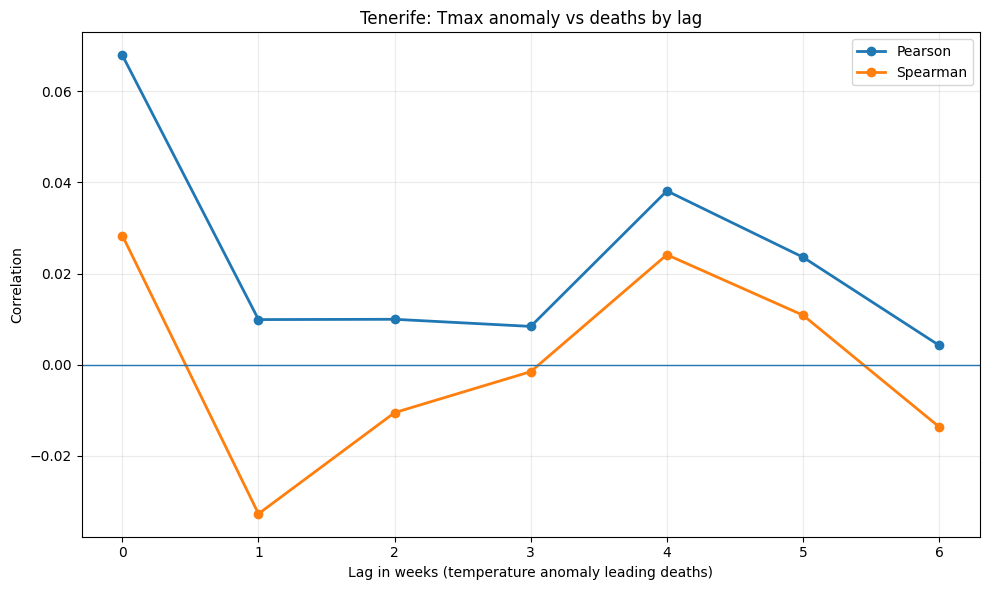

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(lag_anom["lag_weeks"], lag_anom["pearson"], marker="o", linewidth=2, label="Pearson")
plt.plot(lag_anom["lag_weeks"], lag_anom["spearman"], marker="o", linewidth=2, label="Spearman")
plt.axhline(0, linewidth=1)
plt.xticks(lag_anom["lag_weeks"])
plt.xlabel("Lag in weeks (temperature anomaly leading deaths)")
plt.ylabel("Correlation")
plt.title("Tenerife: Tmax anomaly vs deaths by lag")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
p90_anom = df["tmax_anomaly"].quantile(0.90)
p95_anom = df["tmax_anomaly"].quantile(0.95)

df["heat_anom_p90"] = (df["tmax_anomaly"] >= p90_anom).astype(int)
df["heat_anom_p95"] = (df["tmax_anomaly"] >= p95_anom).astype(int)

print("Anomaly thresholds")
print("p90:", round(p90_anom, 2))
print("p95:", round(p95_anom, 2))

print("\nDeaths by heat_anom_p90")
print(df.groupby("heat_anom_p90")["deaths_week"].agg(["count", "mean", "median", "std", "min", "max"]).round(2))

print("\nDeaths by heat_anom_p95")
print(df.groupby("heat_anom_p95")["deaths_week"].agg(["count", "mean", "median", "std", "min", "max"]).round(2))

Anomaly thresholds
p90: 1.86
p95: 2.53

Deaths by heat_anom_p90
               count    mean  median    std    min    max
heat_anom_p90                                            
0                423  137.85   137.0  21.22   92.0  208.0
1                 48  145.65   144.5  24.01  110.0  214.0

Deaths by heat_anom_p95
               count    mean  median    std    min    max
heat_anom_p95                                            
0                447  138.27   137.0  21.70   92.0  214.0
1                 24  145.50   145.0  19.08  110.0  183.0


           anom_bin  anom_mean  deaths_mean  deaths_std   n    se  ci95
0  (-2.893, -1.665]      -2.08       141.27       23.73  48  3.43  6.71
1  (-1.665, -1.204]      -1.42       139.77       20.45  47  2.98  5.85
2  (-1.204, -0.844]      -1.03       136.32       18.56  47  2.71  5.31
3  (-0.844, -0.549]      -0.68       136.74       22.51  47  3.28  6.44
4  (-0.549, -0.321]      -0.42       138.55       23.16  47  3.38  6.62
5   (-0.321, 0.148]      -0.12       138.21       20.50  47  2.99  5.86
6    (0.148, 0.614]       0.40       136.64       20.93  47  3.05  5.98
7    (0.614, 1.119]       0.84       130.94       19.23  47  2.81  5.50
8    (1.119, 1.864]       1.44       141.55       21.20  47  3.09  6.06
9     (1.864, 8.01]       3.11       146.36       23.75  47  3.46  6.79


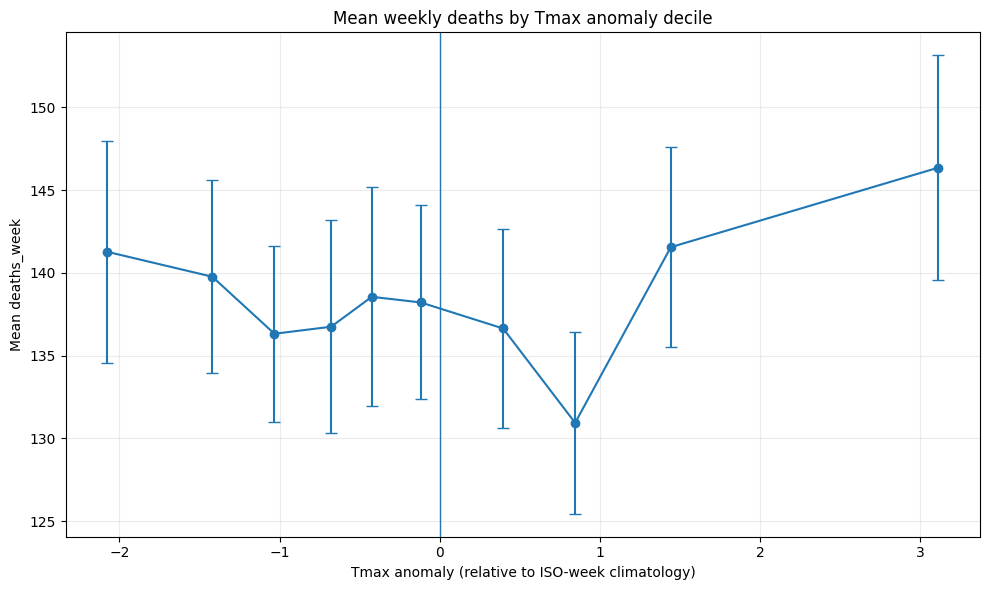

In [33]:
tmp = df[["tmax_anomaly", "deaths_week"]].dropna().copy()
tmp["anom_bin"] = pd.qcut(tmp["tmax_anomaly"], q=10, duplicates="drop")

bin_summary = (
    tmp.groupby("anom_bin", observed=True)
       .agg(
           anom_mean=("tmax_anomaly", "mean"),
           deaths_mean=("deaths_week", "mean"),
           deaths_std=("deaths_week", "std"),
           n=("deaths_week", "size")
       )
       .reset_index()
)

bin_summary["se"] = bin_summary["deaths_std"] / np.sqrt(bin_summary["n"])
bin_summary["ci95"] = 1.96 * bin_summary["se"]

print(bin_summary.round(2))

plt.figure(figsize=(10, 6))
plt.errorbar(
    bin_summary["anom_mean"],
    bin_summary["deaths_mean"],
    yerr=bin_summary["ci95"],
    fmt="-o",
    capsize=4
)
plt.axvline(0, linewidth=1)
plt.title("Mean weekly deaths by Tmax anomaly decile")
plt.xlabel("Tmax anomaly (relative to ISO-week climatology)")
plt.ylabel("Mean deaths_week")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Tras ajustar la temperatura por la climatología semanal, la asociación lineal simple entre temperatura y mortalidad prácticamente desaparece. Sin embargo, el análisis por deciles de anomalía térmica sugiere una posible relación no lineal, con un repunte de la mortalidad en las semanas con anomalías térmicas más altas. Esto indica que el posible efecto del calor, si existe, no se expresa bien como una relación lineal global, sino quizá como un fenómeno concentrado en episodios anómalamente cálidos.

# Variable de Calor Extremo

In [34]:
df = pd.read_parquet(FP).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").copy()

# =========================
# BUILD WEEKLY CLIMATOLOGY + ANOMALY
# =========================

iso = df["week_start"].dt.isocalendar()
df["iso_week"] = iso.week.astype(int)

weekly_clim = (
    df.groupby("iso_week", as_index=False)["tmax_c_mean"]
      .mean()
      .rename(columns={"tmax_c_mean": "tmax_clim_mean"})
)

df = df.merge(weekly_clim, on="iso_week", how="left")
df["tmax_anomaly"] = df["tmax_c_mean"] - df["tmax_clim_mean"]

# =========================
# EXTREME ANOMALY FLAGS
# =========================

p90_anom = df["tmax_anomaly"].quantile(0.90)
p95_anom = df["tmax_anomaly"].quantile(0.95)

df["heat_anom_p90"] = (df["tmax_anomaly"] >= p90_anom).astype(int)
df["heat_anom_p95"] = (df["tmax_anomaly"] >= p95_anom).astype(int)

print("Anomaly thresholds")
print("p90:", round(p90_anom, 2))
print("p95:", round(p95_anom, 2))

print("\nCounts")
print("heat_anom_p90:", df["heat_anom_p90"].sum())
print("heat_anom_p95:", df["heat_anom_p95"].sum())

# =========================
# SUMMARY TABLES
# =========================

print("\nDeaths by heat_anom_p90")
print(
    df.groupby("heat_anom_p90")["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

print("\nDeaths by heat_anom_p95")
print(
    df.groupby("heat_anom_p95")["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

Anomaly thresholds
p90: 1.86
p95: 2.53

Counts
heat_anom_p90: 48
heat_anom_p95: 24

Deaths by heat_anom_p90
               count    mean  median    std    min    max
heat_anom_p90                                            
0                423  137.85   137.0  21.22   92.0  208.0
1                 48  145.65   144.5  24.01  110.0  214.0

Deaths by heat_anom_p95
               count    mean  median    std    min    max
heat_anom_p95                                            
0                447  138.27   137.0  21.70   92.0  214.0
1                 24  145.50   145.0  19.08  110.0  183.0


In [35]:
rows = []

for flag in ["heat_anom_p90", "heat_anom_p95"]:
    for lag in range(0, 4):
        tmp = df[["week_start", flag, "deaths_week"]].copy()
        tmp["deaths_future"] = tmp["deaths_week"].shift(-lag)
        tmp = tmp.dropna()

        summary = (
            tmp.groupby(flag)["deaths_future"]
               .agg(["count", "mean", "median", "std"])
        )

        mean0 = summary.loc[0, "mean"]
        mean1 = summary.loc[1, "mean"]
        diff = mean1 - mean0

        rows.append({
            "flag": flag,
            "lag_weeks": lag,
            "n_exposed": int(summary.loc[1, "count"]),
            "mean_deaths_unexposed": mean0,
            "mean_deaths_exposed": mean1,
            "diff_exposed_minus_unexposed": diff
        })

lag_extreme = pd.DataFrame(rows)
print(lag_extreme.round(2))

            flag  lag_weeks  n_exposed  mean_deaths_unexposed  \
0  heat_anom_p90          0         48                 137.85   
1  heat_anom_p90          1         48                 138.27   
2  heat_anom_p90          2         48                 138.68   
3  heat_anom_p90          3         48                 138.78   
4  heat_anom_p95          0         24                 138.27   
5  heat_anom_p95          1         24                 138.38   
6  heat_anom_p95          2         24                 138.67   
7  heat_anom_p95          3         24                 138.80   

   mean_deaths_exposed  diff_exposed_minus_unexposed  
0               145.65                          7.80  
1               142.08                          3.81  
2               138.65                         -0.03  
3               137.25                         -1.53  
4               145.50                          7.23  
5               143.88                          5.49  
6               138.71       

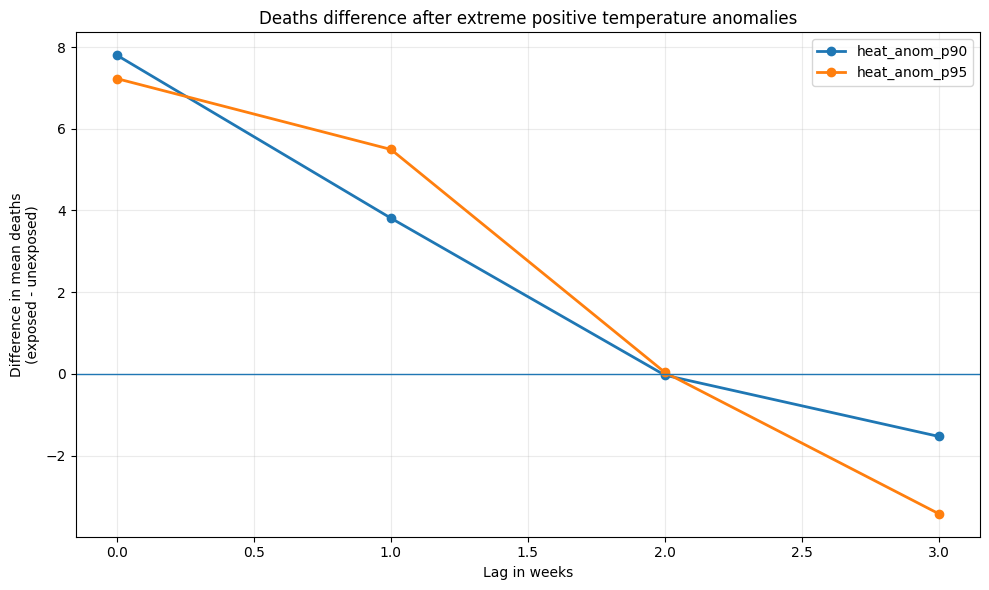

In [36]:
plt.figure(figsize=(10, 6))

for flag in ["heat_anom_p90", "heat_anom_p95"]:
    sub = lag_extreme[lag_extreme["flag"] == flag]
    plt.plot(
        sub["lag_weeks"],
        sub["diff_exposed_minus_unexposed"],
        marker="o",
        linewidth=2,
        label=flag
    )

plt.axhline(0, linewidth=1)
plt.xlabel("Lag in weeks")
plt.ylabel("Difference in mean deaths\n(exposed - unexposed)")
plt.title("Deaths difference after extreme positive temperature anomalies")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Cuando la temperatura máxima media semanal se expresa como anomalía respecto a la climatología semanal, las semanas con calor anómalamente alto muestran una mortalidad media superior a la de las semanas no extremas. Esta diferencia es de aproximadamente 7–8 muertes semanales tanto para el umbral p90 como para el p95. La señal es más clara en la misma semana y se debilita rápidamente en los lags posteriores, lo que sugiere que, si existe un efecto del calor extremo, este no se manifiesta como una relación lineal global ni como un efecto retardado prolongado, sino como un fenómeno concentrado en episodios anómalamente cálidos.

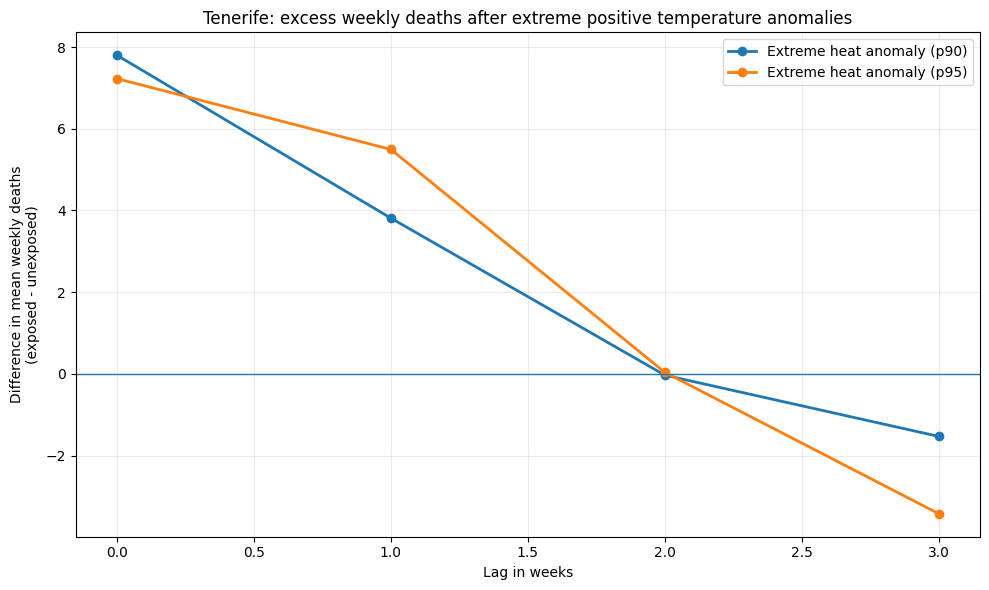

Saved figure: C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\eda\tfe_excess_deaths_after_extreme_heat_anomalies.png


In [37]:
# Asumo que ya tienes lag_extreme construido
plot_df = lag_extreme.copy()

fig, ax = plt.subplots(figsize=(10, 6))

for flag, label in [
    ("heat_anom_p90", "Extreme heat anomaly (p90)"),
    ("heat_anom_p95", "Extreme heat anomaly (p95)")
]:
    sub = plot_df[plot_df["flag"] == flag]
    ax.plot(
        sub["lag_weeks"],
        sub["diff_exposed_minus_unexposed"],
        marker="o",
        linewidth=2,
        label=label
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("Lag in weeks")
ax.set_ylabel("Difference in mean weekly deaths\n(exposed - unexposed)")
ax.set_title("Tenerife: excess weekly deaths after extreme positive temperature anomalies")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()

out_dir = Path(r"C:\dev\projects\heat_mortality_analysis\reports\figures\islas\tenerife\eda")
out_dir.mkdir(parents=True, exist_ok=True)

out_fp = out_dir / "tfe_excess_deaths_after_extreme_heat_anomalies.png"
plt.savefig(out_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_fp)

# Fase 2: Muertes Vs Calima

  calima_proxy_level_v2  count    mean  median    std    min    max    se  \
0             no_calima    276  136.48   135.0  20.24   92.0  197.0  1.22   
1              possible    125  136.96   134.0  20.87  100.0  198.0  1.87   
2              probable     31  140.71   140.0  24.38  103.0  214.0  4.38   
3               intense     39  157.69   158.0  22.51  114.0  208.0  3.60   

   ci95  
0  2.39  
1  3.66  
2  8.58  
3  7.06  


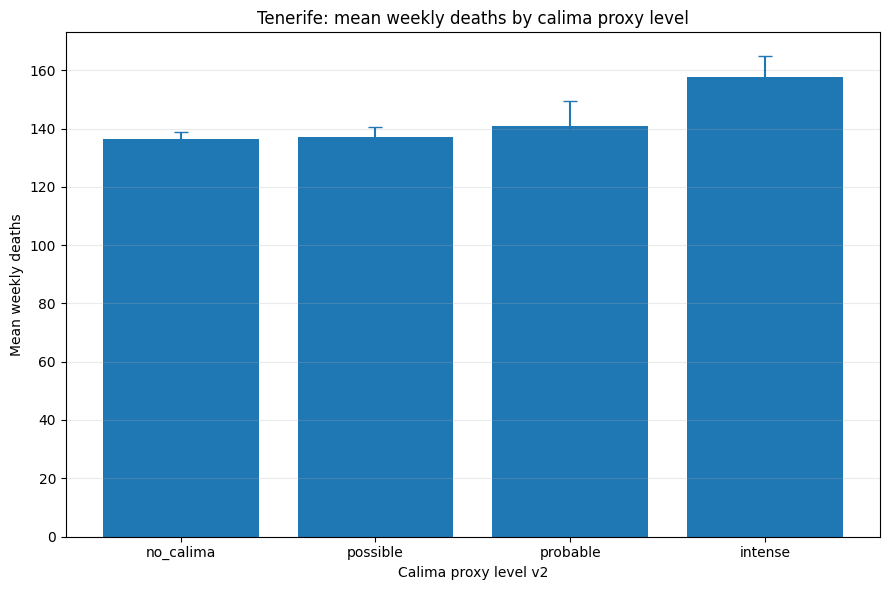

Saved figure: reports\figures\islas\tenerife\eda\tfe_mean_deaths_by_calima_proxy_level_v2.png


In [41]:
# =========================================================
# LOAD CALIMA DATASET
# =========================================================

fp = Path(r"C:/dev/projects/heat_mortality_analysis/data/processed/tenerife/calima/calima_proxy_weekly_tfe_2015_2024_v2.parquet")
df = pd.read_parquet(fp).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

# Orden explícito de niveles
level_order = ["no_calima", "possible", "probable", "intense"]
df["calima_proxy_level_v2"] = pd.Categorical(
    df["calima_proxy_level_v2"],
    categories=level_order,
    ordered=True
)

# =========================================================
# SUMMARY TABLE
# =========================================================

summary = (
    df.groupby("calima_proxy_level_v2", observed=True)["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]

print(summary.round(2))

# =========================================================
# PLOT 1: MEAN DEATHS BY CALIMA LEVEL
# =========================================================

plt.figure(figsize=(9, 6))
plt.bar(summary["calima_proxy_level_v2"], summary["mean"])
plt.errorbar(
    summary["calima_proxy_level_v2"],
    summary["mean"],
    yerr=summary["ci95"],
    fmt="none",
    capsize=5
)

plt.xlabel("Calima proxy level v2")
plt.ylabel("Mean weekly deaths")
plt.title("Tenerife: mean weekly deaths by calima proxy level")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()

out_dir = Path(r"reports/figures/islas/tenerife/eda")
out_dir.mkdir(parents=True, exist_ok=True)

out_fp = out_dir / "tfe_mean_deaths_by_calima_proxy_level_v2.png"

plt.show()

print("Saved figure:", out_fp)

   calima_proxy_score_v2  count    mean  median    std     se   ci95
0                    0.0    221  134.88   134.0  19.84   1.33   2.62
1                    0.5     55  142.89   143.0  20.75   2.80   5.48
2                    1.0     88  129.62   127.5  16.11   1.72   3.37
3                    1.5     37  154.41   153.0  20.71   3.40   6.67
4                    2.0     26  141.65   137.0  26.06   5.11  10.02
5                    2.5      5  135.80   141.0  13.31   5.95  11.67
6                    3.0     13  150.23   147.0  25.39   7.04  13.80
7                    3.5     13  156.54   159.0  19.50   5.41  10.60
8                    4.0      5  173.80   173.0  23.03  10.30  20.18
9                    4.5      8  161.62   161.0  19.52   6.90  13.53


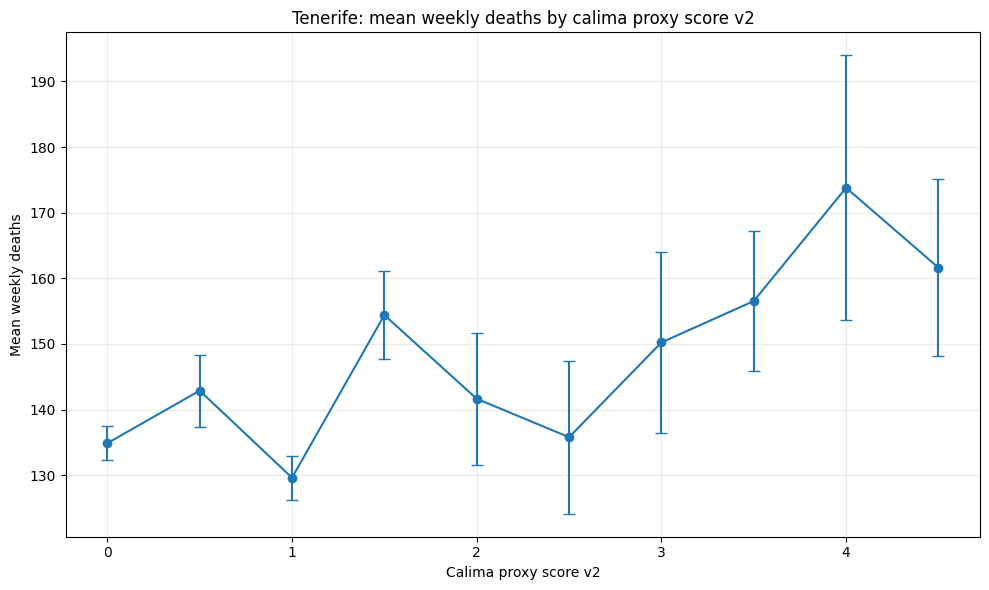

Saved figure: reports\figures\islas\tenerife\eda\tfe_mean_deaths_by_calima_proxy_score_v2.png


In [42]:
# =========================================================
# SUMMARY BY SCORE
# =========================================================

score_summary = (
    df.groupby("calima_proxy_score_v2", observed=True)["deaths_week"]
      .agg(["count", "mean", "median", "std"])
      .reset_index()
)

score_summary["se"] = score_summary["std"] / np.sqrt(score_summary["count"])
score_summary["ci95"] = 1.96 * score_summary["se"]

print(score_summary.round(2))

# =========================================================
# PLOT 2: MEAN DEATHS BY CALIMA SCORE
# =========================================================

plt.figure(figsize=(10, 6))
plt.errorbar(
    score_summary["calima_proxy_score_v2"],
    score_summary["mean"],
    yerr=score_summary["ci95"],
    fmt="-o",
    capsize=4
)

plt.xlabel("Calima proxy score v2")
plt.ylabel("Mean weekly deaths")
plt.title("Tenerife: mean weekly deaths by calima proxy score v2")
plt.grid(True, alpha=0.25)
plt.tight_layout()

out_fp2 = out_dir / "tfe_mean_deaths_by_calima_proxy_score_v2.png"
plt.savefig(out_fp2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_fp2)

In [43]:
# =========================================================
# SIMPLE CONTRASTS
# =========================================================

df["calima_any_v2"] = (df["calima_proxy_level_v2"] != "no_calima").astype(int)
df["calima_intense_v2"] = (df["calima_proxy_level_v2"] == "intense").astype(int)

print("\nDeaths by calima_any_v2")
print(
    df.groupby("calima_any_v2")["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

print("\nDeaths by calima_intense_v2")
print(
    df.groupby("calima_intense_v2")["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)


Deaths by calima_any_v2
               count    mean  median    std    min    max
calima_any_v2                                            
0                276  136.48   135.0  20.24   92.0  197.0
1                195  141.70   140.0  23.14  100.0  214.0

Deaths by calima_intense_v2
                   count    mean  median    std    min    max
calima_intense_v2                                            
0                    432  136.92   135.0  20.72   92.0  214.0
1                     39  157.69   158.0  22.51  114.0  208.0


  calima_proxy_level_v2  count    mean  median    std    min    max    se  \
0             no_calima    276  136.48   135.0  20.24   92.0  197.0  1.22   
1              possible    125  136.96   134.0  20.87  100.0  198.0  1.87   
2              probable     31  140.71   140.0  24.38  103.0  214.0  4.38   
3               intense     39  157.69   158.0  22.51  114.0  208.0  3.60   

   ci95  
0  2.39  
1  3.66  
2  8.58  
3  7.06  

Overall mean deaths_week: 138.64


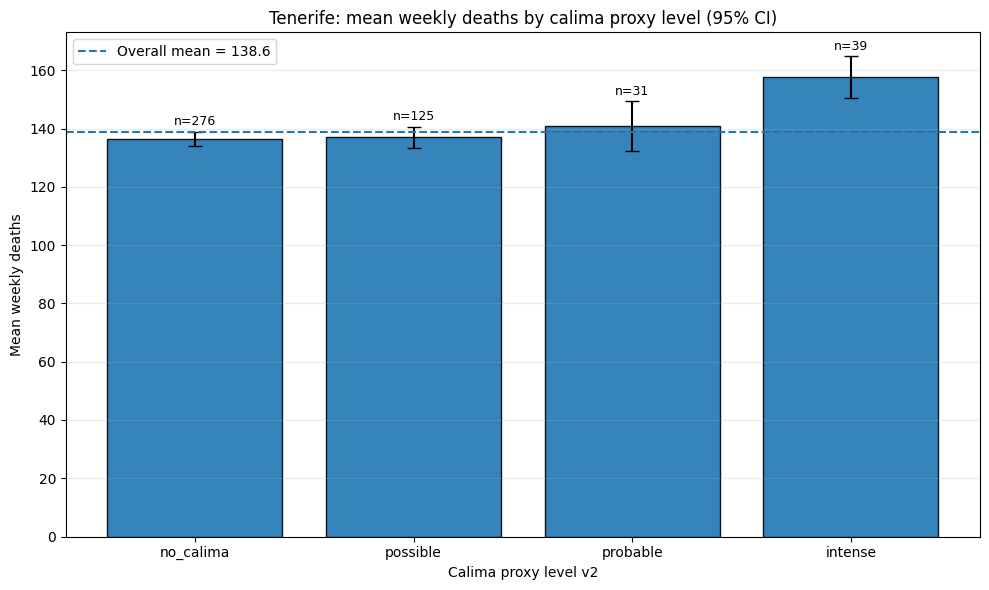

Saved figure: reports\figures\islas\tenerife\eda\tfe_mean_weekly_deaths_by_calima_proxy_level_v2_final.png


In [46]:
# =========================================================
# LOAD
# =========================================================
fp = Path(r"C:/dev/projects/heat_mortality_analysis/data/processed/tenerife/calima/calima_proxy_weekly_tfe_2015_2024_v2.parquet")
df = pd.read_parquet(fp).copy()


df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

level_order = ["no_calima", "possible", "probable", "intense"]
df["calima_proxy_level_v2"] = pd.Categorical(
    df["calima_proxy_level_v2"],
    categories=level_order,
    ordered=True
)

# =========================================================
# SUMMARY
# =========================================================

summary = (
    df.groupby("calima_proxy_level_v2", observed=True)["deaths_week"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]

overall_mean = df["deaths_week"].mean()

print(summary.round(2))
print("\nOverall mean deaths_week:", round(overall_mean, 2))

# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(summary))

bars = ax.bar(
    x,
    summary["mean"],
    yerr=summary["ci95"],
    capsize=5,
    alpha=0.9,
    edgecolor="black"
)

# Global mean line
ax.axhline(
    overall_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall mean = {overall_mean:.1f}"
)

# X labels
ax.set_xticks(x)
ax.set_xticklabels(summary["calima_proxy_level_v2"])

# Labels and title
ax.set_xlabel("Calima proxy level v2")
ax.set_ylabel("Mean weekly deaths")
ax.set_title("Tenerife: mean weekly deaths by calima proxy level (95% CI)")

# Grid
ax.grid(True, axis="y", alpha=0.25)

# Annotate n above bars
for i, row in summary.iterrows():
    ax.text(
        i,
        row["mean"] + row["ci95"] + 1.2,
        f"n={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.legend()
plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

out_dir = Path(r"reports/figures/islas/tenerife/eda")
out_dir.mkdir(parents=True, exist_ok=True)

out_fp = out_dir / "tfe_mean_weekly_deaths_by_calima_proxy_level_v2_final.png"
plt.savefig(out_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_fp)

El análisis exploratorio de muertes semanales frente al nivel de calima proxy muestra una señal débil o nula en los niveles bajos (possible) y un aumento moderado en probable, pero un incremento claro en las semanas clasificadas como intense. La media de muertes semanales pasa de 136.5 en semanas no_calima a 157.7 en semanas de calima intensa, una diferencia aproximada de 21 muertes semanales. Esto sugiere que, en Tenerife, el posible impacto de la calima sobre la mortalidad no parece distribuirse linealmente a lo largo de todo el gradiente, sino concentrarse especialmente en los episodios más intensos.

La mortalidad semanal media en Tenerife se mantiene prácticamente igual entre no_calima y possible, aumenta moderadamente en probable y muestra un incremento claro en intense. Las semanas con calima intensa presentan una media de muertes sustancialmente superior a la media global y a la de las semanas sin calima, lo que sugiere que la asociación entre calima y mortalidad se concentra sobre todo en los episodios más severos.

## Temperatura absoluta cruda engaña por estacionalidad

## Calima intensa sí muestra asociación clara con mayor mortalidad semana

¿las semanas con calor extremo anómalo y calima intensa muestran más muertes que cada exposición por separado?

heat_anom_p90 threshold: 1.86
heat_anom_p90 count: 48
Merged shape: (471, 41)
             heat_calima_combo  count    mean  median    std    min    max  \
0  no_heat | no_intense_calima    398  136.51   135.0  20.28   92.0  198.0   
1                    heat_only     34  141.79   138.5  25.11  110.0  214.0   
2          intense_calima_only     25  159.20   158.0  24.61  120.0  208.0   
3        heat + intense_calima     14  155.00   157.5  18.72  114.0  182.0   

     se  ci95  
0  1.02  1.99  
1  4.31  8.44  
2  4.92  9.65  
3  5.00  9.81  

Overall mean deaths_week: 138.64


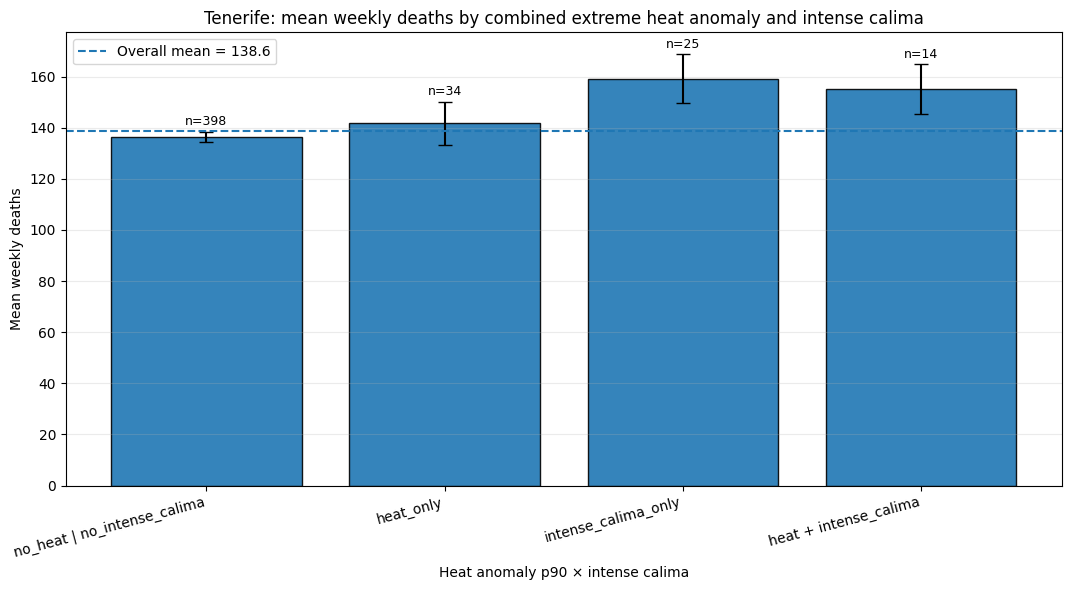

Saved figure: reports\figures\islas\tenerife\eda\tfe_mean_weekly_deaths_heat_anomaly_p90_x_intense_calima.png


In [48]:
# =========================================================
# LOAD MASTER
# =========================================================

fp_master = FP
df = pd.read_parquet(fp_master).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").copy()

# =========================================================
# BUILD TMAX ANOMALY + HEAT FLAG
# =========================================================

iso = df["week_start"].dt.isocalendar()
df["iso_week"] = iso.week.astype(int)

weekly_clim = (
    df.groupby("iso_week", as_index=False)["tmax_c_mean"]
      .mean()
      .rename(columns={"tmax_c_mean": "tmax_clim_mean"})
)

df = df.merge(weekly_clim, on="iso_week", how="left")
df["tmax_anomaly"] = df["tmax_c_mean"] - df["tmax_clim_mean"]

p90_anom = df["tmax_anomaly"].quantile(0.90)
df["heat_anom_p90"] = (df["tmax_anomaly"] >= p90_anom).astype(int)

print("heat_anom_p90 threshold:", round(p90_anom, 2))
print("heat_anom_p90 count:", df["heat_anom_p90"].sum())

# =========================================================
# LOAD CALIMA
# =========================================================

fp_calima = Path(r"C:/dev/projects/heat_mortality_analysis/data/processed/tenerife/calima/calima_proxy_weekly_tfe_2015_2024_v2.parquet")
cal = pd.read_parquet(fp_calima).copy()
cal["week_start"] = pd.to_datetime(cal["week_start"], errors="coerce")

cal["calima_intense_v2"] = (cal["calima_proxy_level_v2"] == "intense").astype(int)

cal = cal[["week_start", "calima_proxy_level_v2", "calima_intense_v2"]].copy()

# =========================================================
# MERGE
# =========================================================

m = df.merge(cal, on="week_start", how="left", validate="one_to_one")

print("Merged shape:", m.shape)

# =========================================================
# 4-GROUP COMBINATION
# =========================================================

def combo_label(row):
    if row["heat_anom_p90"] == 0 and row["calima_intense_v2"] == 0:
        return "no_heat | no_intense_calima"
    elif row["heat_anom_p90"] == 1 and row["calima_intense_v2"] == 0:
        return "heat_only"
    elif row["heat_anom_p90"] == 0 and row["calima_intense_v2"] == 1:
        return "intense_calima_only"
    else:
        return "heat + intense_calima"

m["heat_calima_combo"] = m.apply(combo_label, axis=1)

combo_order = [
    "no_heat | no_intense_calima",
    "heat_only",
    "intense_calima_only",
    "heat + intense_calima",
]

m["heat_calima_combo"] = pd.Categorical(
    m["heat_calima_combo"],
    categories=combo_order,
    ordered=True
)

# =========================================================
# SUMMARY
# =========================================================

summary = (
    m.groupby("heat_calima_combo", observed=True)["deaths_week"]
     .agg(["count", "mean", "median", "std", "min", "max"])
     .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]

overall_mean = m["deaths_week"].mean()

print(summary.round(2))
print("\nOverall mean deaths_week:", round(overall_mean, 2))

# =========================================================
# PLOT
# =========================================================

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(summary))

bars = ax.bar(
    x,
    summary["mean"],
    yerr=summary["ci95"],
    capsize=5,
    alpha=0.9,
    edgecolor="black"
)

ax.axhline(
    overall_mean,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall mean = {overall_mean:.1f}"
)

ax.set_xticks(x)
ax.set_xticklabels(summary["heat_calima_combo"], rotation=15, ha="right")
ax.set_xlabel("Heat anomaly p90 × intense calima")
ax.set_ylabel("Mean weekly deaths")
ax.set_title("Tenerife: mean weekly deaths by combined extreme heat anomaly and intense calima")

ax.grid(True, axis="y", alpha=0.25)

for i, row in summary.iterrows():
    ax.text(
        i,
        row["mean"] + row["ci95"] + 1.2,
        f"n={int(row['count'])}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.legend()
plt.tight_layout()

# =========================================================
# SAVE
# =========================================================

out_dir = Path(r"reports/figures/islas/tenerife/eda")
out_dir.mkdir(parents=True, exist_ok=True)

out_fp = out_dir / "tfe_mean_weekly_deaths_heat_anomaly_p90_x_intense_calima.png"
plt.savefig(out_fp, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_fp)

¿Las semanas con calima, sobre todo calima intensa, tienden a ser también semanas más cálidas o con anomalía térmica positiva?

In [49]:
# =========================================================
# LOAD MASTER
# =========================================================

fp_master = FP
df = pd.read_parquet(fp_master).copy()

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df = df.sort_values("week_start").copy()

# =========================================================
# BUILD TMAX ANOMALY
# =========================================================

iso = df["week_start"].dt.isocalendar()
df["iso_week"] = iso.week.astype(int)

weekly_clim = (
    df.groupby("iso_week", as_index=False)["tmax_c_mean"]
      .mean()
      .rename(columns={"tmax_c_mean": "tmax_clim_mean"})
)

df = df.merge(weekly_clim, on="iso_week", how="left")
df["tmax_anomaly"] = df["tmax_c_mean"] - df["tmax_clim_mean"]

# =========================================================
# LOAD CALIMA
# =========================================================

cal = pd.read_parquet(fp_calima).copy()
cal["week_start"] = pd.to_datetime(cal["week_start"], errors="coerce")

cal = cal[["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]].copy()

# =========================================================
# MERGE
# =========================================================

m = df.merge(cal, on="week_start", how="left", validate="one_to_one")

level_order = ["no_calima", "possible", "probable", "intense"]
m["calima_proxy_level_v2"] = pd.Categorical(
    m["calima_proxy_level_v2"],
    categories=level_order,
    ordered=True
)

# =========================================================
# SUMMARY: TMAX BY CALIMA LEVEL
# =========================================================

tmax_summary = (
    m.groupby("calima_proxy_level_v2", observed=True)["tmax_c_mean"]
     .agg(["count", "mean", "median", "std", "min", "max"])
     .reset_index()
)

tmax_summary["se"] = tmax_summary["std"] / np.sqrt(tmax_summary["count"])
tmax_summary["ci95"] = 1.96 * tmax_summary["se"]

print("TMAX by calima level")
print(tmax_summary.round(2))

# =========================================================
# SUMMARY: TMAX ANOMALY BY CALIMA LEVEL
# =========================================================

anom_summary = (
    m.groupby("calima_proxy_level_v2", observed=True)["tmax_anomaly"]
     .agg(["count", "mean", "median", "std", "min", "max"])
     .reset_index()
)

anom_summary["se"] = anom_summary["std"] / np.sqrt(anom_summary["count"])
anom_summary["ci95"] = 1.96 * anom_summary["se"]

print("\nTMAX ANOMALY by calima level")
print(anom_summary.round(2))

TMAX by calima level
  calima_proxy_level_v2  count   mean  median   std    min    max    se  ci95
0             no_calima    276  25.85   25.84  2.39  20.40  32.26  0.14  0.28
1              possible    125  25.93   25.46  3.06  21.10  33.30  0.27  0.54
2              probable     31  28.34   28.17  3.77  22.36  36.41  0.68  1.33
3               intense     39  25.70   24.97  3.40  21.57  36.94  0.54  1.07

TMAX ANOMALY by calima level
  calima_proxy_level_v2  count  mean  median   std   min   max    se  ci95
0             no_calima    276 -0.46   -0.47  1.07 -2.89  2.44  0.06  0.13
1              possible    125  0.12   -0.22  1.38 -2.39  4.64  0.12  0.24
2              probable     31  2.04    1.86  2.06 -1.10  8.01  0.37  0.72
3               intense     39  1.23    1.23  2.06 -1.78  7.63  0.33  0.65


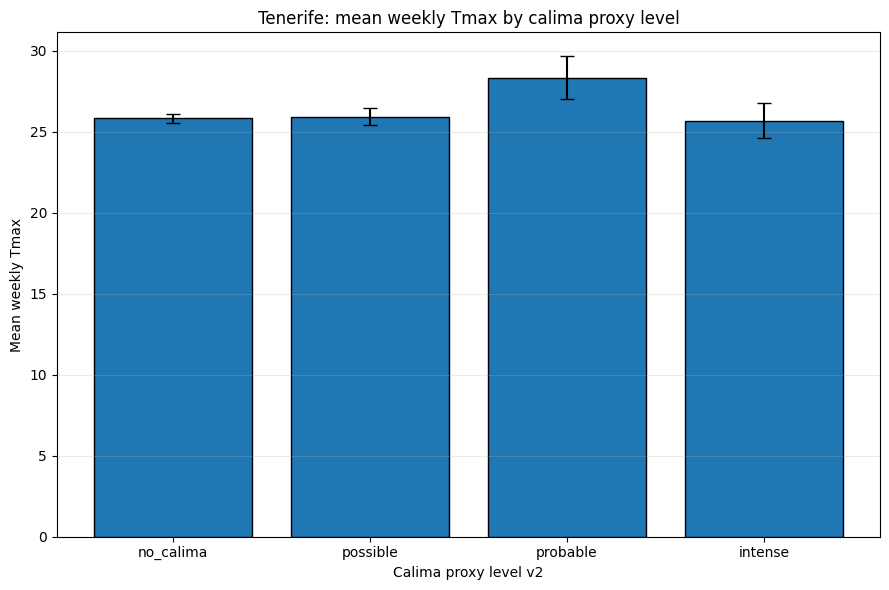

In [50]:
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(tmax_summary))

ax.bar(
    x,
    tmax_summary["mean"],
    yerr=tmax_summary["ci95"],
    capsize=5,
    edgecolor="black"
)

ax.set_xticks(x)
ax.set_xticklabels(tmax_summary["calima_proxy_level_v2"])
ax.set_xlabel("Calima proxy level v2")
ax.set_ylabel("Mean weekly Tmax")
ax.set_title("Tenerife: mean weekly Tmax by calima proxy level")
ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In [51]:
m["calima_intense_v2"] = (m["calima_proxy_level_v2"] == "intense").astype(int)

print("\nTMAX by intense calima yes/no")
print(
    m.groupby("calima_intense_v2")["tmax_c_mean"]
     .agg(["count", "mean", "median", "std", "min", "max"])
     .round(2)
)

print("\nTMAX anomaly by intense calima yes/no")
print(
    m.groupby("calima_intense_v2")["tmax_anomaly"]
     .agg(["count", "mean", "median", "std", "min", "max"])
     .round(2)
)


TMAX by intense calima yes/no
                   count   mean  median   std    min    max
calima_intense_v2                                          
0                    432  26.05   25.85  2.78  20.40  36.41
1                     39  25.70   24.97  3.40  21.57  36.94

TMAX anomaly by intense calima yes/no
                   count  mean  median   std   min   max
calima_intense_v2                                       
0                    432 -0.11   -0.37  1.42 -2.89  8.01
1                     39  1.23    1.23  2.06 -1.78  7.63


las semanas de calima intensa tienden a ser más cálidas de lo normal para su época, aunque no necesariamente sean las semanas con temperatura absoluta más alta de toda la serie.

Los episodios de calima intensa no tienen por qué coincidir con las semanas de temperatura absoluta más alta. En Tenerife, la calima parece asociarse mejor con anomalías térmicas positivas que con valores absolutos extremos de temperatura, lo que sugiere que durante estos episodios la temperatura puede situarse por encima de lo normal para la época sin necesariamente dominar la señal semanal agregada.

# Resumen narrativo de hallazgos EDA — Tenerife

El EDA semanal de Tenerife muestra que la relación entre temperatura y mortalidad depende mucho de cómo se construya la variable térmica. Con la temperatura máxima media semanal absoluta (tmax_c_mean), la asociación con deaths_week aparece como negativa moderada, lo que apunta a un efecto fuerte de la estacionalidad: en la serie completa, las semanas más frías coinciden con mayor mortalidad media. Sin embargo, esta relación se debilita casi por completo cuando la temperatura se expresa como anomalía respecto a la climatología semanal, lo que indica que la señal negativa inicial era en gran parte un artefacto estacional y no una relación lineal simple entre calor y muertes.

Aun así, la temperatura anómala no desaparece del todo del análisis. Las semanas con anomalías térmicas positivas extremas (heat_anom_p90 y heat_anom_p95) presentan una mortalidad media superior a la de las semanas no extremas, con diferencias de aproximadamente 7–8 muertes semanales, concentradas sobre todo en la misma semana o con un retraso muy corto. Esto sugiere que, si existe un efecto del calor en esta escala temporal, no se expresa como una tendencia lineal global, sino más bien como un fenómeno ligado a episodios anómalamente cálidos.

La señal más fuerte del EDA aparece en la calima. El análisis de calima_proxy_level_v2 muestra que la mortalidad apenas cambia entre no_calima y possible, aumenta moderadamente en probable y sube de forma clara en intense. Las semanas de calima intensa alcanzan una media de aproximadamente 157.7 muertes, frente a 136.5 en semanas sin calima, una diferencia de unas 21 muertes semanales. Esto sugiere que la relación entre calima y mortalidad no parece distribuirse de forma lineal a lo largo de todo el gradiente, sino concentrarse especialmente en los episodios más severos.

El cruce entre calor extremo anómalo y calima intensa refuerza esta lectura. Aunque las semanas con calor extremo por sí solas muestran una mortalidad algo mayor que el grupo base, la elevación más marcada aparece en los grupos con calima intensa, y la combinación de ambos factores no supera claramente a la calima intensa por separado. En este EDA, por tanto, la calima intensa emerge como señal más dominante que el calor extremo anómalo.

Por último, el análisis de temperatura y calima sugiere que ambos fenómenos están parcialmente relacionados, pero no son equivalentes. Las semanas con mayor señal de calima tienden a mostrar anomalías térmicas positivas, aunque no necesariamente las temperaturas absolutas más altas de la serie. Esto indica que parte de la señal térmica puede estar embebida en episodios de calima, pero también que la intensidad de la calima depende de otros componentes mejor captados por PM10, humedad baja y baja visibilidad. En conjunto, el EDA de Tenerife apunta a que la calima intensa es la señal ambiental más claramente asociada con aumentos de mortalidad semanal, mientras que la temperatura requiere tratarse con medidas relativas o extremas para no quedar distorsionada por la estacionalidad.

# Narrative summary of EDA findings — Tenerife

The weekly EDA for Tenerife shows that the relationship between temperature and mortality depends strongly on how the temperature variable is defined. Using absolute weekly mean maximum temperature (tmax_c_mean), the association with deaths_week appears moderately negative, pointing to a strong seasonal pattern: across the full series, colder weeks tend to coincide with higher average mortality. However, this relationship almost disappears when temperature is expressed as an anomaly relative to weekly climatology, which suggests that the initial negative signal was largely a seasonal artifact rather than a simple linear relationship between heat and deaths.

That said, temperature does not disappear from the analysis entirely. Weeks with extreme positive temperature anomalies (heat_anom_p90 and heat_anom_p95) show higher mean mortality than non-extreme weeks, with differences of roughly 7–8 weekly deaths, concentrated mainly in the same week or with only a very short delay. This suggests that, if heat has an effect at this temporal scale, it does not appear as a broad linear trend, but rather as a feature of unusually warm episodes.

The clearest signal in the EDA comes from calima. The analysis of calima_proxy_level_v2 shows that mortality changes very little between no_calima and possible, rises moderately in probable, and increases clearly in intense. Weeks classified as intense calima reach an average of about 157.7 deaths, compared with 136.5 in weeks without calima, a difference of roughly 21 weekly deaths. This suggests that the relationship between calima and mortality does not appear to be distributed linearly across the full gradient, but is concentrated especially in the most severe episodes.

The interaction between extreme heat anomaly and intense calima reinforces this interpretation. Although weeks with extreme heat alone show somewhat higher mortality than the baseline group, the strongest increase appears in groups with intense calima, and the combination of both factors does not clearly exceed intense calima on its own. In this EDA, intense calima emerges as a more dominant signal than extreme positive heat anomaly.

Finally, the analysis of temperature and calima suggests that the two phenomena are partly related, but not equivalent. Weeks with stronger calima signals tend to show positive temperature anomalies, although not necessarily the highest absolute temperatures in the series. This indicates that part of the temperature signal may be embedded within calima episodes, but also that calima intensity depends on other components better captured by PM10, low humidity, and low visibility. Overall, the Tenerife EDA suggests that intense calima is the environmental signal most clearly associated with higher weekly mortality, while temperature needs to be treated through relative or extreme measures in order to avoid being distorted by seasonality.